# Анализ оттока клиентов телеком-компании
## Описание проекта

Данный проект посвящён анализу клиентской базы телеком-компании с целью выявления факторов, влияющих на отток клиентов (Churn), а также проверке бизнес-гипотез на основе имеющихся данных.

Анализ выполнен в формате исследовательского ноутбука с использованием Python и библиотек для обработки данных и визуализации.

## Цель работы

Выявить ключевые факторы, влияющие на отток клиентов, и проверить ряд бизнес-гипотез для последующего улучшения удержания пользователей.

## Задачи проекта
Провести первичный анализ и очистку данных
Привести данные к удобному формату (типизация, обработка пропусков)
Выполнить исследовательский анализ (EDA)
Проверить сформулированные гипотезы
Определить закономерности поведения клиентов
Сформировать портрет лояльного клиента
Сделать выводы и предложить рекомендации

## Основные этапы работы
### 1. Загрузка и предобработка данных
### 2. Исследовательский анализ данных (EDA)
### 3. Feature Engineering
### 4. Проверка гипотез
### 5. Анализ оттока
### 6. Формирование выводов


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'seaborn'

In [1]:
df = pd.read_csv('../data/prepare/telco.csv')
pd.set_option('display.max_columns', None)
df.head()

NameError: name 'pd' is not defined

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Приведу названия столбцов в CamelCase

In [5]:
df.columns = [col[0].upper() + col[1:] for col in df.columns]

In [6]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: False, 1: True})
df['Partner'] = df['Partner'].replace({'No': False, 'Yes': True})
df['Dependents'] = df['Dependents'].replace({'No': False, 'Yes': True})
df['PaperlessBilling'] = df['PaperlessBilling'].replace({'No': False, 'Yes': True})
df['Churn'] = df['Churn'].replace({'No': False, 'Yes': True})

C:\Users\dessorokin\AppData\Local\Temp\ipykernel_3224\1781065026.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: False, 1: True})
C:\Users\dessorokin\AppData\Local\Temp\ipykernel_3224\1781065026.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Partner'] = df['Partner'].replace({'No': False, 'Yes': True})
C:\Users\dessorokin\AppData\Local\Temp\ipykernel_3224\1781065026.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future

In [7]:
df[df['TotalCharges'] == ' ']

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,False,True,True,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,True,Bank transfer (automatic),52.55,,False
753,3115-CZMZD,Male,False,False,True,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.25,,False
936,5709-LVOEQ,Female,False,True,True,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,False,Mailed check,80.85,,False
1082,4367-NUYAO,Male,False,True,True,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.75,,False
1340,1371-DWPAZ,Female,False,True,True,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,False,Credit card (automatic),56.05,,False
3331,7644-OMVMY,Male,False,True,True,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,19.85,,False
3826,3213-VVOLG,Male,False,True,True,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.35,,False
4380,2520-SGTTA,Female,False,True,True,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.00,,False
5218,2923-ARZLG,Male,False,True,True,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,True,Mailed check,19.70,,False
6670,4075-WKNIU,Female,False,True,True,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,False,Mailed check,73.35,,False


In [8]:
df.loc[df['Tenure'] == 0, 'TotalCharges'] = 0

In [9]:
df['Gender'] = df['Gender'].astype('category')
df['Tenure'] = pd.to_numeric(arg=df['Tenure'], downcast='integer')
df['PhoneService'] = df['PhoneService'].astype('category')
df['MultipleLines'] = df['MultipleLines'].astype('category')
df['InternetService'] = df['InternetService'].astype('category')
df['OnlineSecurity'] = df['OnlineSecurity'].astype('category')
df['OnlineBackup'] = df['OnlineBackup'].astype('category')
df['DeviceProtection'] = df['DeviceProtection'].astype('category')
df['TechSupport'] = df['TechSupport'].astype('category')
df['StreamingTV'] = df['StreamingTV'].astype('category')
df['StreamingMovies'] = df['StreamingMovies'].astype('category')
df['MonthlyCharges'] = pd.to_numeric(arg=df['MonthlyCharges'], downcast='float')
df['TotalCharges'] = pd.to_numeric(arg=df['TotalCharges'], downcast='float')

In [10]:
bins = [0, 1, 13, 25, 49, 72, 100]
labels = ['Новый покупатель', 'до 1 года', '1-2 года', '2-4 года', '4-6 лет', '6+ лет']

df['TenureGroup'] = pd.cut(df['Tenure'], bins=bins, labels=labels, right=False)

In [11]:
df['TenureGroup'].value_counts()

TenureGroup
до 1 года           2175
4-6 лет             1877
2-4 года            1594
1-2 года            1024
6+ лет               362
Новый покупатель      11
Name: count, dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   CustomerID        7043 non-null   object  
 1   Gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   bool    
 3   Partner           7043 non-null   bool    
 4   Dependents        7043 non-null   bool    
 5   Tenure            7043 non-null   int8    
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

In [13]:
df.describe()

,Tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761696,2279.734375
std,24.559481,30.090048,2266.794434
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.549988
50%,29.000000,70.349998,1394.550049
75%,55.000000,89.849998,3786.599976
max,72.000000,118.750000,8684.799805


Аномалий не выявлено

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['CustomerID'].duplicated().sum()

np.int64(0)

Дубликатов не выявлено

# Подтверждение или опровержение гипотез

1. Покупатели с партнёром чаще берут MultipleLines PhoneService


In [16]:
print(df.groupby(['Partner', 'MultipleLines'])['MultipleLines'].agg('count'))

w_partner_ml = (df[df['Partner'] == True]['MultipleLines'] == 'Yes').mean()
wo_partner_ml = (df[df['Partner'] == False]['MultipleLines'] == 'Yes').mean()
print()
print(f'Доля абонентов с партнёром, имеющих MultipleLines: {w_partner_ml.round(2)}')
print(f'Доля абонентов без партнёра, имеющих MultipleLines: {wo_partner_ml.round(2)}')

Partner  MultipleLines   
False    No                  1981
         No phone service     371
         Yes                 1289
True     No                  1409
         No phone service     311
         Yes                 1682
Name: MultipleLines, dtype: int64

Доля абонентов с партнёром, имеющих MultipleLines: 0.49
Доля абонентов без партнёра, имеющих MultipleLines: 0.35


C:\Users\dessorokin\AppData\Local\Temp\ipykernel_3224\898732879.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['Partner', 'MultipleLines'])['MultipleLines'].agg('count'))


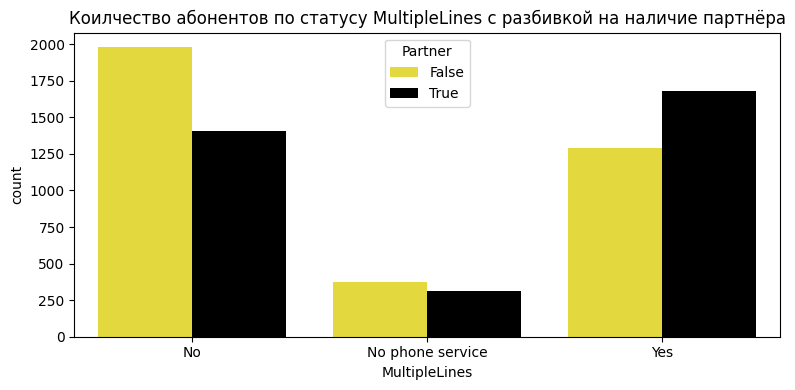

In [17]:
plt.figure(figsize=(8, 4
                    ))
sns.countplot(data=df, 
              x='MultipleLines',
              hue='Partner',
                palette=['#fff123', '#000000']
              )
plt.title('Коилчество абонентов по статусу MultipleLines с разбивкой на наличие партнёра')
plt.xlabel('MultipleLines')
plt.ylabel('count')
plt.tight_layout()
plt.show()

Из графика видим, что действительно доля людей со статусом `MultipleLines = Yes` клиентов с партнёром 0.49 против 0.35 без партнёра

<hr>

2. Для InternetService = Fiber Optic реже берут OnlineSecurity OnlineBackup DeviceProtection потому что думают о том что уверены в волокне

In [18]:
print('Для общей выборки:')
print(f'Доля клиентов с OnlineSecurity = "Yes": {round(len(df[df['OnlineSecurity'] == 'Yes']) / len(df), 2)}, а количество: {len(df[df['OnlineSecurity'] == 'Yes'])} из {len(df)}')
print(f'Доля клиентов с OnlineBackup = "Yes": {round(len(df[df['OnlineBackup'] == 'Yes']) / len(df), 2)}, а количество: {len(df[df['OnlineBackup'] == 'Yes'])} из {len(df)}')
print(f'Доля клиентов с DeviceProtection = "Yes": {round(len(df[df['DeviceProtection'] == 'Yes']) / len(df), 2)}, а количество: {len(df[df['DeviceProtection'] == 'Yes'])} из {len(df)}')
print()
print('Для InternetService = \'Fiber Opric\':')
print(f'Доля клиентов с OnlineSecurity = "Yes": {round(len(df[(df['OnlineSecurity'] == 'Yes') & (df['InternetService'] == 'Fiber optic')]) / len(df[df['InternetService'] == 'Fiber optic']), 2)}, а количество: {len(df[(df['OnlineSecurity'] == 'Yes') & (df['InternetService'] == 'Fiber optic')])} из {len(df[df['InternetService'] == 'Fiber optic'])}')
print(f'Доля клиентов с OnlineBackup = "Yes": {round(len(df[(df['OnlineBackup'] == 'Yes') & (df['InternetService'] == 'Fiber optic')]) / len(df[df['InternetService'] == 'Fiber optic']), 2)}, а количество: {len(df[(df['OnlineBackup'] == 'Yes') & (df['InternetService'] == 'Fiber optic')])} из {len(df[df['InternetService'] == 'Fiber optic'])}')
print(f'Доля клиентов с DeviceProtection = "Yes": {round(len(df[(df['DeviceProtection'] == 'Yes') & (df['InternetService'] == 'Fiber optic')]) / len(df[df['InternetService'] == 'Fiber optic']), 2)}, а количество: {len(df[(df['DeviceProtection'] == 'Yes') & (df['InternetService'] == 'Fiber optic')])} из {len(df[df['InternetService'] == 'Fiber optic'])}')

Для общей выборки:
Доля клиентов с OnlineSecurity = "Yes": 0.29, а количество: 2019 из 7043
Доля клиентов с OnlineBackup = "Yes": 0.34, а количество: 2429 из 7043
Доля клиентов с DeviceProtection = "Yes": 0.34, а количество: 2422 из 7043

Для InternetService = 'Fiber Opric':
Доля клиентов с OnlineSecurity = "Yes": 0.27, а количество: 839 из 3096
Доля клиентов с OnlineBackup = "Yes": 0.43, а количество: 1343 из 3096
Доля клиентов с DeviceProtection = "Yes": 0.44, а количество: 1357 из 3096


Text(0.5, 1.0, 'Использование сервисов: общая vs Fiber')

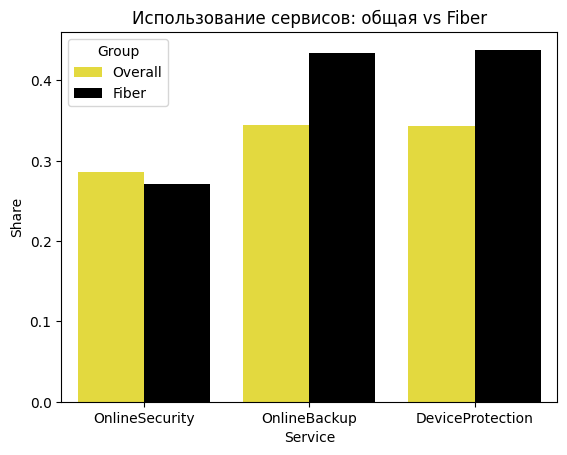

In [19]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection']

overall_share = [len(df[df[serv] == 'Yes']) / len(df) for serv in services]
fiber_share = [
    len(df[(df[s] == 'Yes') & (df['InternetService'] == 'Fiber optic')]) /
    len(df[df['InternetService'] == 'Fiber optic'])
    for s in services
]

df_plot = pd.DataFrame({
    'Service': services,
    'Overall': overall_share,
    'Fiber': fiber_share
})

df_plot_melt = df_plot.melt (
    id_vars='Service',
    var_name='Group',
    value_name='Share'
)

sns.barplot(
    data=df_plot_melt,
    x='Service',
    y='Share',
    hue='Group',
    palette=['#fff123', '#000000']
)
plt.title('Использование сервисов: общая vs Fiber')

Гипотеза опровергнута, наблюдается обратная зависимость: у пользователей с оптоволокном чаще установлены OnlineBackup(0.34 против 0.43) и DeviceProtection(0.34 против 0.44), а OnlineSecurity находится на прежнем уровне.

<Axes: xlabel='Service', ylabel='Count'>

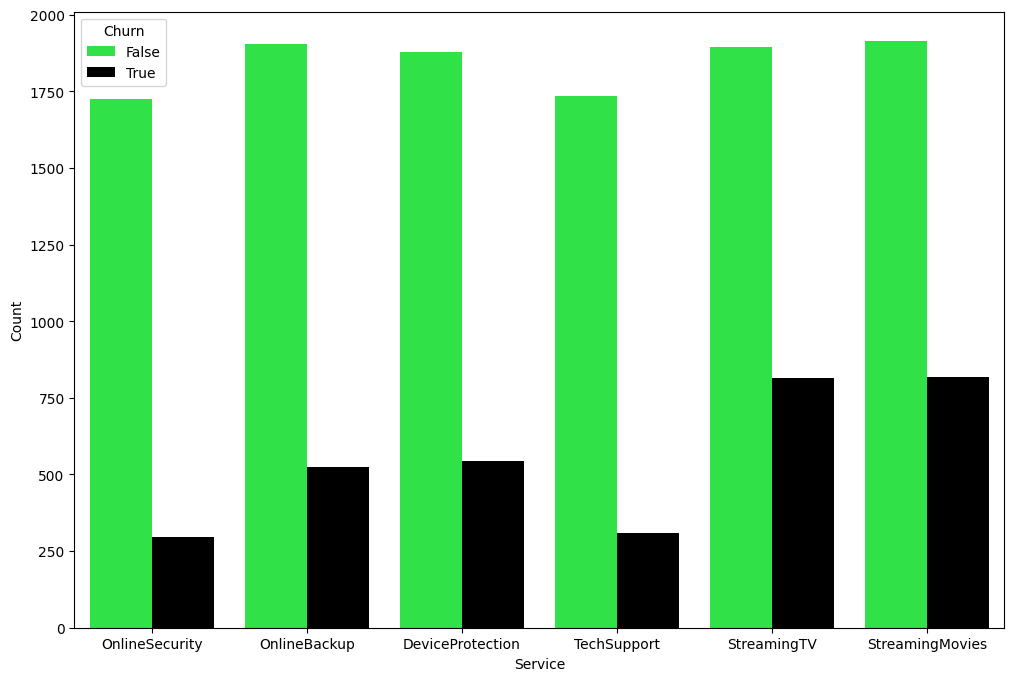

In [20]:
df_services = (df[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']] == 'Yes').groupby(df['Churn']).sum().reset_index()

plt.figure(figsize=(12,8))
df_services_melt = df_services.melt(
    id_vars='Churn',
    var_name='Service',
    value_name='Count'
)

sns.barplot(
    data=df_services_melt,
    x='Service',
    y='Count',
    hue='Churn',
    palette=['#12ff32', '#000000']
)

Пользователи с флагом `Yes` Во всех сервисах уходят из компании реже на 60-80%

<hr>

3. SeniorCitizen = 1 чаще берут Contract с One year	или Two year.

<Axes: xlabel='Contract', ylabel='CustomerID'>

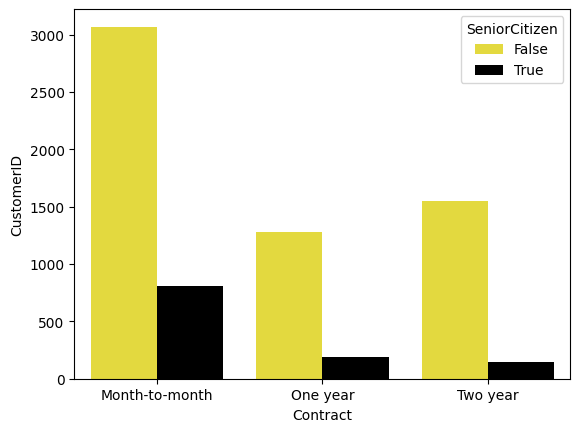

In [21]:
df_seniors = df.groupby(['SeniorCitizen', 'Contract'], as_index=False).agg({
    'CustomerID': 'count'
})

sns.barplot(
    data=df_seniors,
    x='Contract',
    y='CustomerID',
    hue='SeniorCitizen',
    palette=['#fff123', '#000000']
)

Гипотеза не подвердилась, а наоборот, по данным выходит, что для пожилых людей ежемесячный тариф оплаты приобретают в 4 раза чаще чем годовой и в 5 раз чаще чем двухгодовой тарифы

In [22]:
df.groupby(['SeniorCitizen', 'Contract']).agg({
    'CustomerID': 'count',
    'Tenure': 'mean',
    'MonthlyCharges': 'median',
    'TotalCharges': 'median',
    'Churn': 'mean'
})

CustomerID     Tenure  MonthlyCharges  \
SeniorCitizen Contract                                                
False         Month-to-month        3068  16.684159       69.550003   
              One year              1283  40.612627       64.650002   
              Two year              1550  55.918065       60.500000   
True          Month-to-month         807  23.178439       83.800003   
              One year               190  51.715789       94.550003   
              Two year               145  65.468966       89.099998   

                              TotalCharges     Churn  
SeniorCitizen Contract                                
False         Month-to-month    554.250000  0.395698  
              One year         2347.850098  0.106781  
              Two year         3338.699951  0.027097  
True          Month-to-month   1381.800049  0.546468  
              One year         4737.100098  0.152632  
              Two year         5968.399902  0.041379

In [23]:
print(f'Доля стариков, ушедших из комапнии: {df[df['SeniorCitizen'] == True]['Churn'].mean()}')
print(f'Доля молодых, ушедших из комапнии: {df[df['SeniorCitizen'] == False]['Churn'].mean()}')

Доля стариков, ушедших из комапнии: 0.4168126094570928
Доля молодых, ушедших из комапнии: 0.23606168446026096


Посмотрим на причины такой разницы по оттоку

In [24]:
df_teen = df[df['SeniorCitizen'] == False]
df_old = df[df['SeniorCitizen'] == True]

In [25]:
df_teen.describe(include='all')

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
count,5901,5901,5901,5901,5901,5901.000000,5901,5901,5901,5901,5901,5901,5901,5901,5901,5901,5901,5901,5901.000000,5901.000000,5901,5901
unique,5901,2,1,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2,6
top,3186-AJIEK,Male,False,False,False,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,NaN,NaN,False,до 1 года
freq,1,2981,5901,3072,3882,NaN,5323,3017,2265,2690,2474,2471,2643,2292,2290,3068,3295,1771,NaN,NaN,4508,1855
mean,NaN,NaN,NaN,NaN,NaN,32.192171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.847443,2177.023682,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,24.628639,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.316040,2233.118164,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.600000,359.399994,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.800003,1291.349976,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.699997,3562.500000,NaN,NaN


In [26]:
df_old.describe(include='all')

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
count,1142,1142,1142,1142,1142,1142.000000,1142,1142,1142,1142,1142,1142,1142,1142,1142,1142,1142,1142,1142.000000,1142.000000,1142,1142
unique,1142,2,1,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2,5
top,8361-LTMKD,Male,True,True,False,NaN,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,True,Electronic check,NaN,NaN,False,до 1 года
freq,1,574,1142,573,1051,NaN,1038,665,831,808,614,624,830,572,595,807,876,594,NaN,NaN,666,320
mean,NaN,NaN,NaN,NaN,NaN,33.295972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.820358,2810.465088,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,24.188530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.764027,2364.314209,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.950001,19.450001,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.150002,689.575012,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.849998,2263.750000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,56.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.074999,4600.312622,NaN,NaN


При сравнении этих датасетов я не заметил сильных различий кроме столбца Dependents: старики чаще чем в 90% случаев не имеют иждевнцов, против примерно половины у молодых.

In [27]:
df.groupby(['SeniorCitizen', 'TenureGroup']).agg({
    'CustomerID': 'count',
    'Tenure': 'mean',
    'MonthlyCharges': 'median',
    'TotalCharges': 'median',
    'Churn': 'mean'
})

C:\Users\dessorokin\AppData\Local\Temp\ipykernel_3224\2187047728.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['SeniorCitizen', 'TenureGroup']).agg({


CustomerID     Tenure  MonthlyCharges  \
SeniorCitizen TenureGroup                                               
False         Новый покупатель          11   0.000000       25.750000   
              до 1 года               1855   4.775202       53.650002   
              1-2 года                 856  18.366822       59.500000   
              2-4 года                1313  36.292460       65.650002   
              4-6 лет                 1560  61.347436       78.699997   
              6+ лет                   306  72.000000       86.650002   
True          Новый покупатель           0        NaN             NaN   
              до 1 года                320   4.640625       74.474998   
              1-2 года                 168  18.273810       82.324997   
              2-4 года                 281  35.718861       89.699997   
              4-6 лет                  317  61.198738       94.000000   
              6+ лет                    56  72.000000      100.500000   

                                TotalCharges     Churn  
SeniorCitizen TenureGroup                               
False         Новый покупатель      0.000000  0.000000  
              до 1 года           165.000000  0.442049  
              1-2 года           1075.850098  0.246495  
              2-4 года           2227.800049  0.159177  
              4-6 лет            4616.075195  0.095513  
              6+ лет             6242.275391  0.013072  
True          Новый покупатель           NaN       NaN  
              до 1 года           236.375000  0.678125  
              1-2 года           1385.500000  0.494048  
              2-4 года           2952.850098  0.412811  
              4-6 лет            5483.899902  0.182965  
              6+ лет             7290.400391  0.035714

Так как в первый год контракта более 60% пенсионеров уходит, а при этом в данных нет ощутимых различий кроме столбца Dependents, я считаю, что скорее всего старики часто обращаются с вопросами касаемо продукта в силу возраста, и не получая должного отклика уходят из компании (при этом не ощущая тягость кормления иждевенцов). Необходимо проработать вопрос на уровне показателей удовлетворенности клиентов

- Больше половины пожилых клиентов с месячно подпиской уходи из продукта. одна из причин - высокая ежемес. плата (78 против 63 у молодых)
- В целом у пожилых клиентов TotalCharged выше в 2 раза.
- Наименьший отток у контракта на два года по обеим категориям возраста клиентов

<hr>

4. Для tenure = 72 MonthlyCharges заметно ниже среднего.


In [28]:
avg_monthly_overall = df['MonthlyCharges'].median()
avg_monthly_72 = df[df['Tenure'] == 72]['MonthlyCharges'].median()

print(f'Средняя ежемесячная стоимость: {avg_monthly_overall.round(2)}')
print(f'Средняя ежемесячная стоимость для пользователей с 72+ месяцами: {avg_monthly_72.round(2)}')


Средняя ежемесячная стоимость: 70.3499984741211
Средняя ежемесячная стоимость для пользователей с 72+ месяцами: 89.08000183105469


In [29]:
avg_churn_overall = df['Churn'].mean()
avg_churn_72 = df[df['Tenure'] == 72]['Churn'].mean()

print(f'Доля оттока по всей выборке: {avg_churn_overall.round(2)}')
print(f'Доля оттока по выборке с 72 месяцами: {avg_churn_72.round(2)}')

Доля оттока по всей выборке: 0.27
Доля оттока по выборке с 72 месяцами: 0.02


Гипотеза так же опровергнута. В среднем у пользователей с 72 и более месяцев контракта медиана MonthlyCharges больше на 19 ед.
Однако доля оттока для пользователей с 72+ месяцами на порядок меньше: 0.27 для общей выборки и 0.02 для выборки с 6+ лет контракта

In [30]:
df[df['Tenure'] == 72].describe(include='all')

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
count,362,362,362,362,362,362.0,362,362,362,362,362,362,362,362,362,362,362,362,362.000000,362.000000,362,362
unique,362,2,2,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2,1
top,2234-XADUH,Male,False,True,False,NaN,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,True,Bank transfer (automatic),NaN,NaN,False,6+ лет
freq,1,185,306,311,200,NaN,331,280,163,236,252,259,224,241,245,343,221,160,NaN,NaN,356,362
mean,NaN,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.695854,5812.444824,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.956764,2308.907471,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.299999,1304.800049,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.837502,4684.612305,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.075001,6387.074951,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,108.275002,7750.962646,NaN,NaN


### Анализируя клиентов с 6+ годами взаимодействия с компанией, формируется портрет лояльного клиента:
<span style="background-color:#fff123; color:black; width: 1200px">
- Клиент не пенсионер <br>
- Клиент с партнёром <br>
- Имеет иждевенца <br>
- Подключен по оптоволокну <br>
- Подключены все доп. услуги <br>
- Контракт на два года <br>
- Расплачивается по безналичному расчёту <br>
</span>

Однако в текущем продукте таких клиентов меньше 5% от общего количества, поэтому необходимо уделять больше внимания текущим клиентам, программе лояльности и нацелиться на retention rate, а не привлечение новых.

<hr>

Вытекающая из п.4 гипотеза:

Для Tenure < 4 доля оттока сильно выше остальной выборки

TenureGroup
до 1 года           2175
4-6 лет             1877
2-4 года            1594
1-2 года            1024
6+ лет               362
Новый покупатель      11
Name: count, dtype: int64


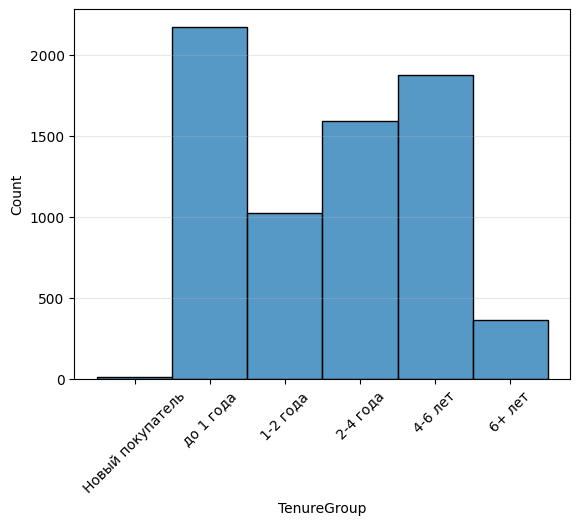

In [ ]:
print(df['TenureGroup'].value_counts())
sns.histplot(
    data=df,
    x='TenureGroup'
).tick_params('x', rotation=45)
plt.grid(axis='y', alpha=0.3)

    Tenure  Churn  ChurnToAll
0        1    380    0.203317
1        2    123    0.065811
2        3     94    0.050294
3        4     83    0.044409
4        5     64    0.034243
..     ...    ...         ...
67      68      9    0.004815
68      69      8    0.004280
69      70     11    0.005886
70      71      6    0.003210
71      72      6    0.003210

[72 rows x 3 columns]


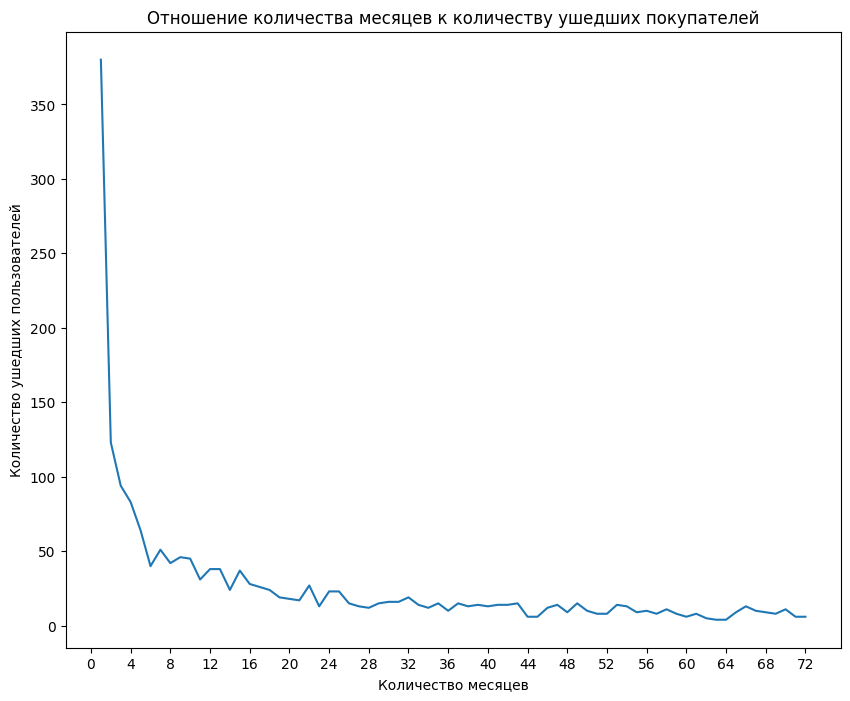

In [43]:
plt.figure(figsize=(10,8))
tenure_churn_relation = df[df['Tenure'] > 0].groupby('Tenure').agg({
    'Churn': 'sum'
}).reset_index()
tenure_churn_relation['ChurnToAll'] = tenure_churn_relation['Churn'] / df['Churn'].sum()
print(tenure_churn_relation)
plt.plot(tenure_churn_relation['Tenure'], tenure_churn_relation['Churn'])
plt.xlabel('Количество месяцев')
plt.xticks(ticks=([i*4 for i in range(19)]))
plt.ylabel('Количество ушедших пользователей')
plt.title('Отношение количества месяцев к количеству ушедших покупателей')
plt.show()

В первые 3 месяца отваливается большая часть клиентов: более 30% от всего числа ушедших. 

In [33]:
df[(df['Tenure'] <= 3) & (df['Churn'] == True)].describe(include='all')

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
count,597,597,597,597,597,597.000000,597,597,597,597,597,597,597,597,597,597,597,597,597.000000,597.000000,597,597
unique,597,2,2,2,2,NaN,2,3,3,3,3,3,3,3,3,2,2,4,NaN,NaN,1,1
top,6894-LFHLY,Female,False,False,False,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,NaN,NaN,True,до 1 года
freq,1,304,473,488,517,NaN,529,401,333,489,461,455,488,394,399,595,412,350,NaN,NaN,597,597
mean,NaN,NaN,NaN,NaN,NaN,1.520938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.019604,95.641541,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,0.751942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.779381,67.648193,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.850000,18.850000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.700001,49.950001,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.750000,74.949997,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.250000,127.099998,NaN,NaN


По описанию группы с `количеством месяцев <= 3` и `Churn == True` видим, что большинство клиентов этой выборки - не пожилые, не имеющие партнёра и иждевенцев. Эти факторы дают нам понять, что при малейших неудобствах клиент не будет лоялен к компании из-за его "свободы от обязателсьтв", поэтому более вероятно что выберет конкурента.

Так как тарифы для всех групп ушедших клиентов примерно одинаковы, то вариант того, что клиентов не устраивает цена -  мы отметаем. Возможно, клиент испытвал частые сбои. Стоит отметить, что клиенты из этого сегмента чаще не имеют подключенных сервисов. УЧитывая целевую группу клиентов и их вовлеченность в подключенные серивсы - они явный бенефит компании, поэтому стоит активнее продвигать эти сервисы для клиентов.


<hr>

5. Покупатели с иждевенцами имеют Tenure выше среднего и Churn ниже среднего 


In [34]:
depend_relation = df.groupby('Dependents').agg({
    'Tenure': 'mean',
    'Churn': 'mean',
    'MonthlyCharges': 'median',
    'TotalCharges': 'median'
}).reset_index()
depend_relation

,Dependents,Tenure,Churn,MonthlyCharges,TotalCharges
0,False,29.806000,0.312791,73.900002,1322.550049
1,True,38.368246,0.154502,60.974998,1536.750000


В среднем клиенты без иждевенцев имеют меньшую ежемесячную плату на 18%, однако в среднем LTV этих клиентов чуть больше, в отличии от клиентов без иждевенцев (1536 против 1322 соответсвтенно)

C:\Users\dessorokin\AppData\Local\Temp\ipykernel_3224\2303127081.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


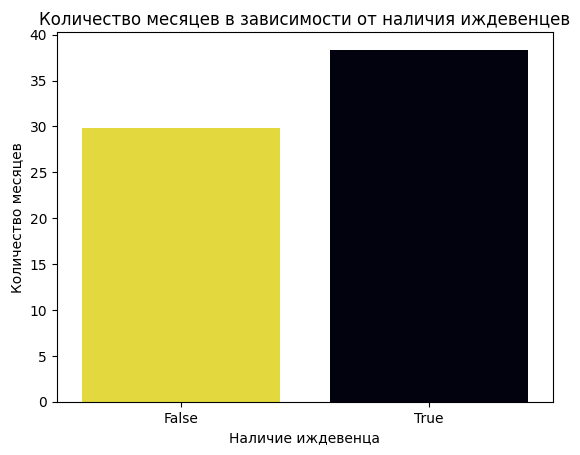

In [35]:
sns.barplot(
    data=depend_relation,
    x='Dependents',
    y='Tenure',
    palette=['#fff123', '#000010']
)
plt.title('Количество месяцев в зависимости от наличия иждевенцев')
plt.xlabel('Наличие иждевенца')
plt.ylabel('Количество месяцев')
plt.show()

C:\Users\dessorokin\AppData\Local\Temp\ipykernel_3224\1406817346.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


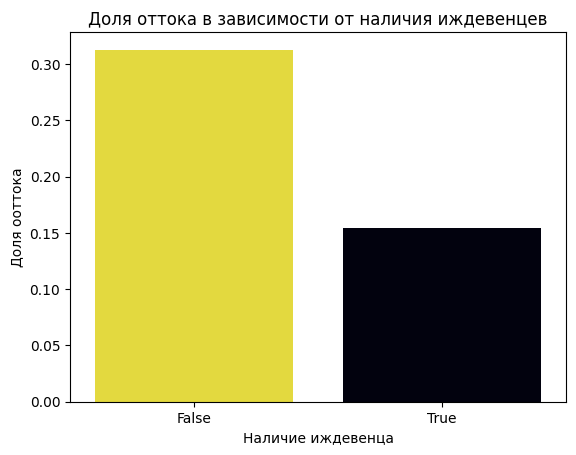

In [36]:
sns.barplot(
    data=depend_relation,
    x='Dependents',
    y='Churn',
    palette=['#fff123', '#000010']
)
plt.title('Доля оттока в зависимости от наличия иждевенцев')
plt.xlabel('Наличие иждевенца')
plt.ylabel('Доля ооттока')
plt.show()

Гипотеза подтверждена, т.к. среднее коилчество месяцев контракта у клиентов без еждевенца 29, а с ним - 38.
Доля оттока же для клиентов с еждевенцем - 0.15 против 0.32 у клиентов без него.

<hr>

6. Женщины чаще имеют флаг TechSupport = 1 

In [37]:
df.groupby('Gender').agg({
    'MonthlyCharges': 'mean',
    'Churn': 'mean'
})

C:\Users\dessorokin\AppData\Local\Temp\ipykernel_3224\713080972.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Gender').agg({


,MonthlyCharges,Churn
Gender,,
Female,65.204247,0.269209
Male,64.327484,0.261603


In [38]:
gender_df = df.groupby(['Gender', 'TechSupport'])['CustomerID'].count().reset_index()


C:\Users\dessorokin\AppData\Local\Temp\ipykernel_3224\1257882482.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_df = df.groupby(['Gender', 'TechSupport'])['CustomerID'].count().reset_index()


<Axes: xlabel='Gender', ylabel='CustomerID'>

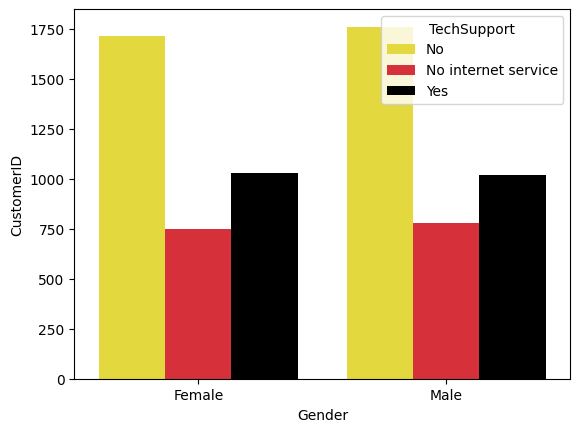

In [39]:
sns.barplot(
    data=gender_df,
    x='Gender',
    y='CustomerID',
    hue='TechSupport',
    palette=['#fff123', '#f21521', '#000000']
)

Гипотеза опровергнута. Распределение между мужчинами и женщинами среди категории TechSupport идентично.

<hr>


7. Метод оплаты счёта влияет на отток

In [40]:
df_payment_method = df.groupby('PaymentMethod').agg(
    Churned=('Churn', 'mean'),
    Count=('CustomerID', 'count'),
    MonthlyCharge=('MonthlyCharges', 'median')
).reset_index()

df_payment_method['Count_relative'] = df_payment_method['Count'] / len(df)
df_payment_method


,PaymentMethod,Churned,Count,MonthlyCharge,Count_relative
0,Bank transfer (automatic),0.167098,1544,73.099998,0.219225
1,Credit card (automatic),0.152431,1522,73.025002,0.216101
2,Electronic check,0.452854,2365,80.550003,0.335794
3,Mailed check,0.191067,1612,34.700001,0.228880


monthlyucharges у mailed check!!!!1

Из распределения видим, что метод электронных платежей в среднем дороже остальных и имеет наибольший уровень оттока покупателей.

Есть вероятность, что с этим методом оплаты возникают какие-либо проблемы со стороны подрядчиков, отчего клиенты негодуют и уходят

# Выводы

### Данные были предобработаны:
- Были подобраны подходящие типы данных для каждой из колонок, что сэкономио память
- Аномальных значений и дубликатов не найдено
- Пропуски были обнаружены в столбце `TotalCharges`. При детальной проработке обнаружил, что у таких строк `Tenure` = 0 (по всей видимости новый клиент), поэтому `TotalCharges` я приравнял к 0
### Кратко по гипотезам:
1. доля людей со статусом `MultipleLines = Yes` клиентов с партнёром 0.49 против 0.35 без партнёра, что подтверждает гипотезу №1
2. у пользователей с оптоволокном чаще установлены OnlineBackup(0.34 против 0.43) и DeviceProtection(0.34 против 0.44), а OnlineSecurity находится на прежнем уровне, что опровергает гипотезу №2
3. для пожилых людей ежемесячный тариф оплаты приобретают в 4 раза чаще чем годовой и в 5 раз чаще чем двухгодовой тарифы, что опровеграет гипотезу №3.
4. В среднем у пользователей с 72 и более месяцев контракта медиана MonthlyCharges больше на 19 ед, однако доля оттока для пользователей с 72+ месяцами на порядок меньше: 0.27 для общей выборки и 0.02 для выборки с 6+ лет контракта. Гипотеза №4 опровергнута
5. среднее коилчество месяцев контракта у клиентов без еждевенца 29, а с ним - 38, а доля оттока для клиентов с еждевенцем - 0.15 против 0.32 у клиентов без него. Это подтверждает гипотезу №5.
6.  Распределение между мужчинами и женщинами среди категории TechSupport идентично. Гипотеза №6 опровергнута


### Рекоммендации для продукта

1. Стоит уделить внимание клиентам с иждевенцами, так как они склонны к меньшему оттоку и дольше остаются с компанией. 
2. Для клиентов с партнёром можно предусмотреть скидку на продукт с параметром MultipleLines.
3. Стоит обратить внимание на общую тарификацию пожилых людей, потому что для подписки с ежемес оплатой отток более 50%, а TotalCharges больше в 2 раза по сравнению с более молодым поколением.
4. Стоит добавить registration_date, last_purhcase_date и churn_date. Это позволит делать более глубокую аналитику и поможет понять, из-за чего высокая доля пользователей уходит в первые 3 месяца регистрации.
5. Добавить метрику удовлетворения пользователей.
6. Активнее продвигать доп. сервисы внутри продукта, так как клиенты, имеющие их - уходят гораздо реже